# Data checking

Loads the raw CMHC rent and vacancy exports with the project loader and confirms the result is complete before any analysis uses it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from alberta_rent_watch.cmhc import load_cmhc_data

In [2]:
raw_data_directory = PROJECT_ROOT / "data" / "raw"

rent = load_cmhc_data(raw_data_directory)
rent.head()

year,city,average_rent,vacancy_rate
i64,str,f64,f64
2000,"""Edmonton, Alberta""",603.0,1.3
2001,"""Edmonton, Alberta""",657.0,0.9
2002,"""Edmonton, Alberta""",710.0,1.6
2003,"""Edmonton, Alberta""",723.0,3.5
2004,"""Edmonton, Alberta""",729.0,5.2


## Completeness checks

Every year from 2000 to 2025 should appear exactly once, with no missing rent or vacancy values.

In [3]:
years = rent["year"].to_list()
print(f"Shape: {rent.shape}")
print(f"Years: {min(years)}–{max(years)}")
print(f"Unique consecutive years: {years == list(range(2000, 2026))}")
print(f"Missing values: {rent.null_count().sum_horizontal().item()}")
rent.describe()

Shape: (26, 4)
Years: 2000–2025
Unique consecutive years: True
Missing values: 0


statistic,year,city,average_rent,vacancy_rate
str,f64,str,f64,f64
"""count""",26.0,"""26""",26.0,26.0
"""null_count""",0.0,"""0""",0.0,0.0
"""mean""",2012.5,null,1079.538462,3.611538
"""std""",7.648529,null,273.236049,1.961903
"""min""",2000.0,"""Edmonton, Alberta""",603.0,0.9
"""25%""",2006.0,null,810.0,1.7
"""50%""",2013.0,null,1144.0,3.8
"""75%""",2019.0,null,1261.0,4.9
"""max""",2025.0,"""Edmonton, Alberta""",1598.0,7.1


## Rent series

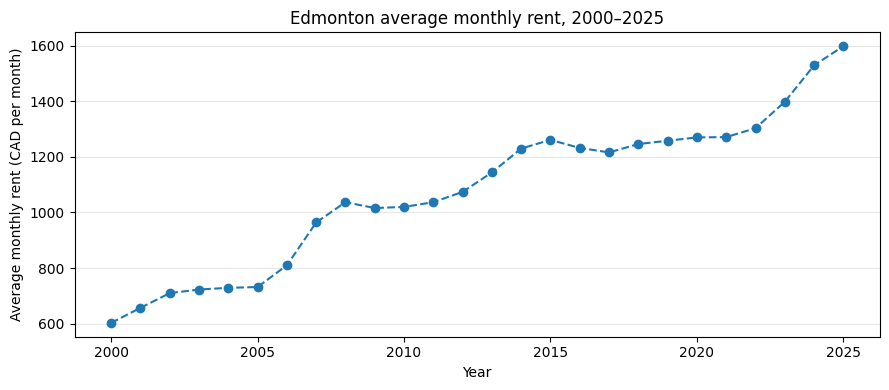

In [4]:
#sort by year
rent_history = rent.sort("year")
#outline of graph
fig, ax = plt.subplots(figsize=(9, 4))
#plot the data
ax.plot(
    rent_history["year"],
    rent_history["average_rent"],
    marker="o",
    linestyle="--",
)
ax.set_title("Edmonton average monthly rent, 2000–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Average monthly rent (CAD per month)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()